In [23]:
import matplotlib.pyplot as plt
import yfinance as yf
import pandas as pd
import numpy as np

[*********************100%***********************]  1 of 1 completed

216 trades taken
Bull FVG 5 Average returns: 0.06%
108 Medium Sized FVGs
Medium Bull FVG 5 Average returns: 0.2%
133 trades taken
Bear FVG 5 Average returns: 0.31%
67 Medium Sized FVGs
Medium Bear FVG 5 Average returns: 0.21%


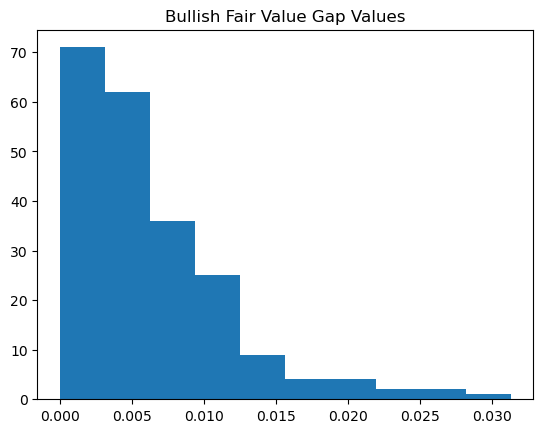

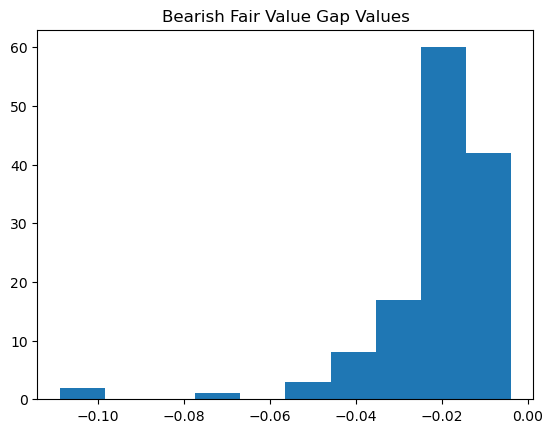

In [43]:
TICKER = 'SPY'
LOOKBACK = 1000
HOLDING_PERIOD = 5

def get_data():
    df = yf.download(TICKER, start='2020-01-01')
    df.columns = df.columns.get_level_values(0)


    return df.iloc[-LOOKBACK:,:]

def bull_fvg(df):
    
    df['High_2prev'] = df['High'].shift(2)
    df['Bull_FVG'] = (df['Low'] > df['High_2prev']).astype(int)
    df['Bull_FVG_val'] = (df['Low'] - df['High_2prev']) * df['Bull_FVG'] / df['Close']

    fvg_subset = df[df['Bull_FVG_val'] > 0]
    plt.hist(fvg_subset['Bull_FVG_val'], bins=10)
    plt.title('Bullish Fair Value Gap Values')
 
    return df

def bear_fvg(df):
    
    df['Low_2prev'] = df['Low'].shift(2)
    df['Bear_FVG'] = (df['High'] < df['Low_2prev']).astype(int)
    df['Bear_FVG_val'] = (df['Low'] - df['Low_2prev']) * df['Bear_FVG'] / df['Close']

    fvg_subset = df[df['Bear_FVG_val'] < 0]
    plt.figure()
    plt.hist(fvg_subset['Bear_FVG_val'], bins=10)
    plt.title('Bearish Fair Value Gap Values')
 
    return df

def assess_bull_FVG(df,holding_period=HOLDING_PERIOD):
    #5 days holdig period returns
    df[f'Returns_In_{holding_period}_Periods'] = df['Close'].shift(-holding_period) / df['Close']

    fvg_subset = df[df['Bull_FVG_val'] > 0]
    print(f'{len(fvg_subset)} trades taken')
    print(f'Bull FVG {holding_period} Average returns: {round((fvg_subset[f'Returns_In_{holding_period}_Periods'].mean() -1 ) * 100, 2)}%')

    lower = fvg_subset['Bull_FVG_val'].quantile(.25)
    upper = fvg_subset['Bull_FVG_val'].quantile(.75)

    fvg_medium_val = fvg_subset[
        (fvg_subset['Bull_FVG_val'] >= lower) & (fvg_subset['Bull_FVG_val'] <= upper)
    ]
    print(f"{len(fvg_medium_val)} Medium Sized FVGs")
    print(f'Medium Bull FVG {holding_period} Average returns: {round((fvg_medium_val[f'Returns_In_{holding_period}_Periods'].mean() -1 ) * 100, 2)}%')


    return df


def assess_bear_FVG(df,holding_period=HOLDING_PERIOD):
    #5 days holdig period returns
    df[f'Price_{HOLDING_PERIOD}P_Ago'] = df['Close'].shift(-holding_period) / df['Close']
    fvg_subset = df[df['Bear_FVG_val'] < 0]
    print(f'{len(fvg_subset)} trades taken')
    print(f'Bear FVG {holding_period} Average returns: {round((fvg_subset[f'Returns_In_{holding_period}_Periods'].mean() -1 ) * 100, 2)}%')


    lower = fvg_subset['Bear_FVG_val'].quantile(.25)
    upper = fvg_subset['Bear_FVG_val'].quantile(.75)

    fvg_medium_val = fvg_subset[
        (fvg_subset['Bear_FVG_val'] >= lower) & (fvg_subset['Bear_FVG_val'] <= upper)
    ]
    print(f"{len(fvg_medium_val)} Medium Sized FVGs")
    print(f'Medium Bear FVG {holding_period} Average returns: {round((fvg_medium_val[f'Returns_In_{holding_period}_Periods'].mean() -1 ) * 100, 2)}%')

    return df


def main():

    df = get_data()
    df = bull_fvg(df)
    df = bear_fvg(df)
    df = assess_bull_FVG(df)
    df = assess_bear_FVG(df)

    return df

df = main()